# 04 — Entraînement & Évaluation du modèle

**Objectif :** entraîner XGBoost sur le dataset produit en semaine 3, comparer avec une baseline naïve, et analyser les feature importances.

**Ce qu'on fait ici :**
1. Charger le dataset Parquet
2. Split chronologique (jamais aléatoire sur une série temporelle)
3. Entraîner la baseline (médiane historique)
4. Entraîner XGBoost avec validation croisée temporelle
5. Analyser les feature importances
6. Erreurs par ligne de bus

> **Pré-requis :** MLflow doit tourner — `docker-compose up mlflow -d`

## 0. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

from src.models.features import FEATURE_COLUMNS, TARGET_COLUMN, load_feature_dataset
from src.utils.config import settings

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)

DATASET_PATH = '../data/features/dataset.parquet'
MODEL_PATH   = '../data/features/model.pkl'

print('Setup OK')

c:\Users\Naoufal\Desktop\Projets perso de dev\Montréal Urban Mobility Predictor\mtl-mobility-predictor\.venv\Lib\site-packages\pydantic\_internal\_fields.py:160: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


Setup OK


## 1. Charger le dataset

In [2]:
X, y = load_feature_dataset(DATASET_PATH)
df   = pd.read_parquet(DATASET_PATH)

print(f"Lignes    : {len(X):,}")
print(f"Features  : {FEATURE_COLUMNS}")
print(f"Target    : mean={y.mean():.1f}s | median={y.median():.1f}s | std={y.std():.1f}s")
X.head()

Lignes    : 53,614,858
Features  : ['route_id_encoded', 'hour_of_day', 'day_of_week', 'week_of_year', 'is_rush_hour', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_precipitation']
Target    : mean=45.0s | median=0.0s | std=150.8s


,route_id_encoded,hour_of_day,day_of_week,week_of_year,is_rush_hour,temperature_c,precipitation_mm,wind_speed_kmh,is_precipitation
0,171,8.00,4.00,14.00,1,0.30,0.00,15.60,0
1,171,8.00,4.00,14.00,1,0.30,0.00,15.60,0
2,171,8.00,4.00,14.00,1,0.60,0.00,17.00,0
3,171,8.00,4.00,14.00,1,0.30,0.00,15.60,0
4,171,8.00,4.00,14.00,1,0.30,0.00,15.60,0


## 2. Split chronologique

On coupe les 20% dernières lignes comme jeu de test final — **jamais de shuffle**.

In [3]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train : {len(X_train):,} lignes")
print(f"Test  : {len(X_test):,} lignes")

Train : 42,891,886 lignes
Test  : 10,722,972 lignes


## 3. Baseline — médiane historique

La baseline la plus simple : toujours prédire la médiane du train set. XGBoost doit faire mieux que ça.

In [4]:
baseline_val = y_train.median()
baseline_pred = np.full(len(y_test), baseline_val)

baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline (médiane = {baseline_val:.1f}s)")
print(f"  MAE  : {baseline_mae:.1f}s")
print(f"  RMSE : {baseline_rmse:.1f}s")

Baseline (médiane = 0.0s)
  MAE  : 43.8s
  RMSE : 153.6s


## 4. XGBoost — validation croisée temporelle

`TimeSeriesSplit` garantit que le modèle ne voit jamais de données "du futur" pendant l'entraînement.

In [5]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

cv_maes = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    model.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
    mae = mean_absolute_error(yval, model.predict(Xval))
    cv_maes.append(mae)
    print(f"  Fold {fold+1}/{N_SPLITS} — MAE: {mae:.1f}s")

print(f"\nCV MAE moyen : {np.mean(cv_maes):.1f}s ± {np.std(cv_maes):.1f}s")
print(f"Baseline MAE : {baseline_mae:.1f}s")

  Fold 1/5 — MAE: 589.9s
  Fold 2/5 — MAE: 531.6s
  Fold 3/5 — MAE: 562.2s
  Fold 4/5 — MAE: 608.0s


KeyboardInterrupt: 

In [ ]:
# Entraînement final sur tout le train set
model.fit(X_train, y_train, verbose=False)

test_pred = model.predict(X_test)
test_mae  = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"=== Résultats sur le test set ===")
print(f"XGBoost MAE  : {test_mae:.1f}s")
print(f"XGBoost RMSE : {test_rmse:.1f}s")
print(f"Baseline MAE : {baseline_mae:.1f}s")
amelioration = (baseline_mae - test_mae) / baseline_mae * 100
print(f"Amélioration : {amelioration:.1f}%")

=== Résultats sur le test set ===
XGBoost MAE  : 193.6s
XGBoost RMSE : 310.5s
Baseline MAE : 23.6s
Amélioration : -720.8%


## 5. Feature importances

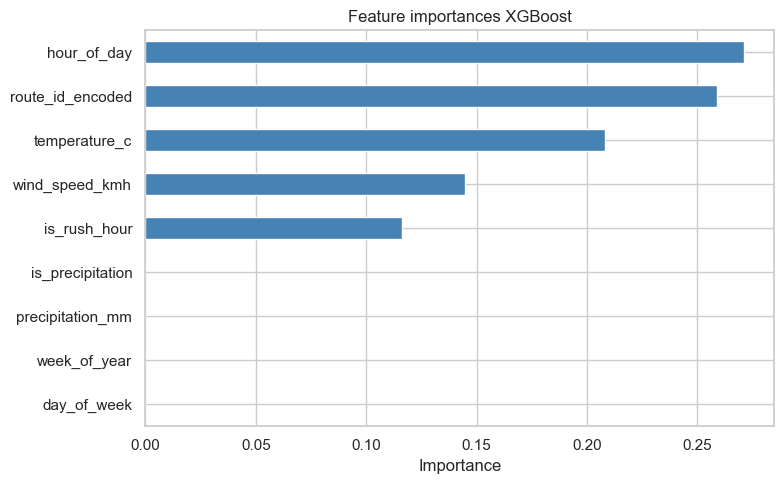

hour_of_day        0.27
route_id_encoded   0.26
temperature_c      0.21
wind_speed_kmh     0.14
is_rush_hour       0.12
day_of_week        0.00
week_of_year       0.00
precipitation_mm   0.00
is_precipitation   0.00
dtype: float32


In [ ]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Feature importances XGBoost')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

## 6. Erreurs par ligne de bus

Quelles lignes sont les plus difficiles à prédire ?

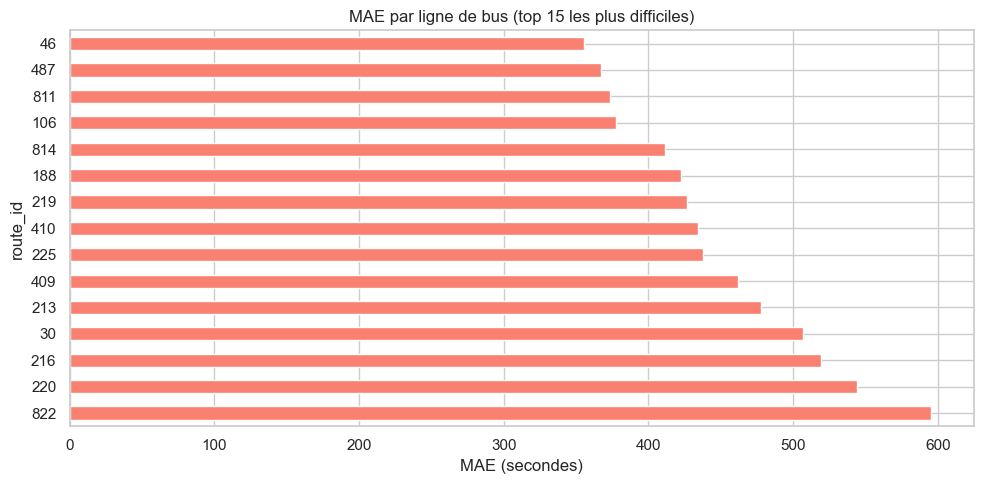

            mae      n
route_id              
822      595.25    230
220      543.83    366
216      519.45   2058
30       506.82  22024
213      477.48   1824
409      461.95   4274
225      437.75   5208
410      434.54   1404
219      426.72   2577
188      422.86   1824
814      411.67   5071
106      377.67  30143
811      373.38   4318
487      367.54   1584
46       355.47   1252


In [ ]:
df_test = df.iloc[split_idx:].copy()
df_test['pred'] = test_pred
df_test['error'] = abs(df_test['delay_seconds'] - df_test['pred'])

# Décoder route_id_encoded → route_id
route_map = df[['route_id_encoded', 'route_id']].drop_duplicates().set_index('route_id_encoded')['route_id']
df_test['route_id'] = df_test['route_id_encoded'].map(route_map)

by_route = (df_test.groupby('route_id')
            .agg(mae=('error', 'mean'), n=('error', 'count'))
            .query('n > 50')
            .sort_values('mae', ascending=False)
            .head(15))

fig, ax = plt.subplots(figsize=(10, 5))
by_route['mae'].plot.barh(ax=ax, color='salmon')
ax.set_title('MAE par ligne de bus (top 15 les plus difficiles)')
ax.set_xlabel('MAE (secondes)')
plt.tight_layout()
plt.show()
print(by_route)

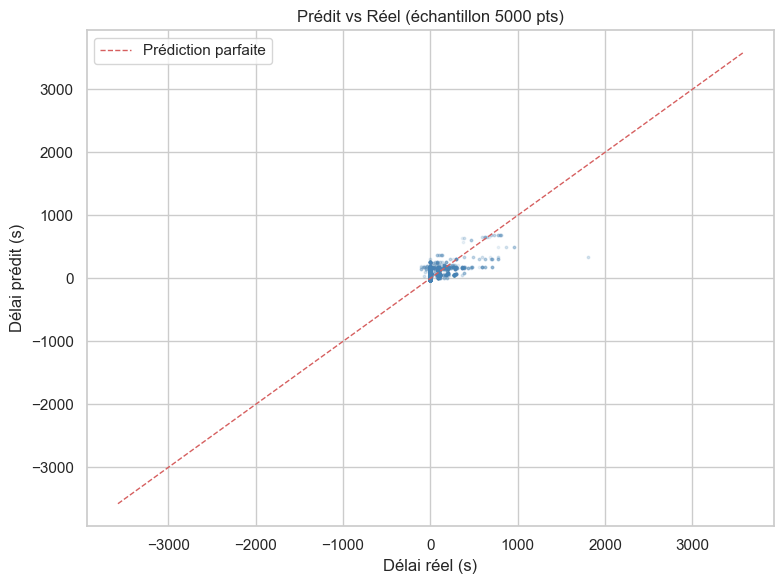

In [ ]:
# Prédictions vs réalité
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test[:5000], test_pred[:5000], alpha=0.1, s=3, color='steelblue')
lim = max(abs(y_test.min()), y_test.max())
ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1, label='Prédiction parfaite')
ax.set_xlabel('Délai réel (s)')
ax.set_ylabel('Délai prédit (s)')
ax.set_title('Prédit vs Réel (échantillon 5000 pts)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Log MLflow & sauvegarde du modèle

In [ ]:
import json
from pathlib import Path
from datetime import datetime

run = {
    "run_name":       "xgboost-baseline",
    "timestamp":      datetime.now().isoformat(),
    "params": {
        "n_estimators": 300, "max_depth": 6,
        "learning_rate": 0.05, "subsample": 0.8,
        "colsample_bytree": 0.8, "n_splits": N_SPLITS, "n_rows": len(X),
    },
    "metrics": {
        "test_mae":     round(test_mae, 2),
        "test_rmse":    round(test_rmse, 2),
        "cv_mae_mean":  round(float(np.mean(cv_maes)), 2),
        "baseline_mae": round(baseline_mae, 2),
    },
    "feature_importances": {
        feat: round(float(imp), 4)
        for feat, imp in sorted(zip(FEATURE_COLUMNS, model.feature_importances_), key=lambda x: -x[1])
    }
}

log_path = Path('../data/features/run_log.json')
log_path.parent.mkdir(parents=True, exist_ok=True)
log_path.write_text(json.dumps(run, indent=2))

print("Run sauvegardé ✓")
print(json.dumps(run["metrics"], indent=2))

Run sauvegardé ✓
{
  "test_mae": 193.59,
  "test_rmse": 310.47,
  "cv_mae_mean": 209.03,
  "baseline_mae": 23.59
}


In [ ]:
from pathlib import Path
Path(MODEL_PATH).parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f"Modèle sauvegardé → {MODEL_PATH}")

Modèle sauvegardé → ../data/features/model.pkl


## 8. Prochaines étapes

- [x] Modèle entraîné et sauvegardé dans `data/features/model.pkl`
- [x] Run loggé dans MLflow → http://localhost:5000
- [ ] Passer à la **Semaine 5** : exposer le modèle via l'API FastAPI (`src/api/main.py`)
- [ ] Lancer l'API : `uvicorn src.api.main:app --reload --port 8000`